In [1]:
import numpy as np

from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
simulator = AerSimulator()
sampler = Sampler(mode=simulator)
estimator = Estimator(mode=simulator)

In [3]:
Z = SparsePauliOp(data=["Z"], coeffs=[1])

In [4]:
Z

SparsePauliOp(['Z'],
              coeffs=[1.+0.j])

In [5]:
Z.to_matrix()

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

In [26]:
params = ParameterVector(name=r"$\theta$", length=1)
bit = ClassicalRegister(size=1, name="bit")
qubit = QuantumRegister(size=1, name="qubit")
qc = QuantumCircuit(qubit, bit)

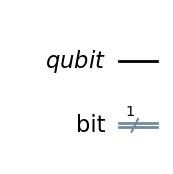

In [27]:
qc.draw(output="mpl", style="clifford")

In [28]:
qc.ry(theta=params[0], qubit=qubit)
qc.measure(qubit=qubit, cbit=bit)

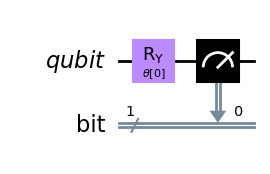

In [29]:
qc.draw(output="mpl", style="clifford")

In [30]:
angles = np.linspace(0, 4*np.pi, 101)

In [31]:
angles

array([ 0.        ,  0.12566371,  0.25132741,  0.37699112,  0.50265482,
        0.62831853,  0.75398224,  0.87964594,  1.00530965,  1.13097336,
        1.25663706,  1.38230077,  1.50796447,  1.63362818,  1.75929189,
        1.88495559,  2.0106193 ,  2.136283  ,  2.26194671,  2.38761042,
        2.51327412,  2.63893783,  2.76460154,  2.89026524,  3.01592895,
        3.14159265,  3.26725636,  3.39292007,  3.51858377,  3.64424748,
        3.76991118,  3.89557489,  4.0212386 ,  4.1469023 ,  4.27256601,
        4.39822972,  4.52389342,  4.64955713,  4.77522083,  4.90088454,
        5.02654825,  5.15221195,  5.27787566,  5.40353936,  5.52920307,
        5.65486678,  5.78053048,  5.90619419,  6.03185789,  6.1575216 ,
        6.28318531,  6.40884901,  6.53451272,  6.66017643,  6.78584013,
        6.91150384,  7.03716754,  7.16283125,  7.28849496,  7.41415866,
        7.53982237,  7.66548607,  7.79114978,  7.91681349,  8.04247719,
        8.1681409 ,  8.29380461,  8.41946831,  8.54513202,  8.67

In [32]:
pubs = [(qc, [value]) for value in angles]
sampler_job = sampler.run(pubs=pubs, shots=100)

In [33]:
sampler_result = sampler_job.result()

In [38]:
sampler_result[10].data.bit.get_counts()

{'1': 29, '0': 71}

In [16]:
params = ParameterVector(name=r"$\theta$", length=1)
qubit = QuantumRegister(size=1, name="qubit")
qc = QuantumCircuit(qubit)

In [17]:
qc.ry(theta=params[0], qubit=qubit)

In [18]:
angles = np.linspace(0, 4*np.pi, 101)

In [19]:
pubs = [(qc, Z, [value]) for value in angles]
estimator_job = estimator.run(pubs=pubs, precision=1/np.sqrt(100))

In [20]:
estimator_result = estimator_job.result()

In [24]:
estimator_result[3].data.evs

array(0.94)

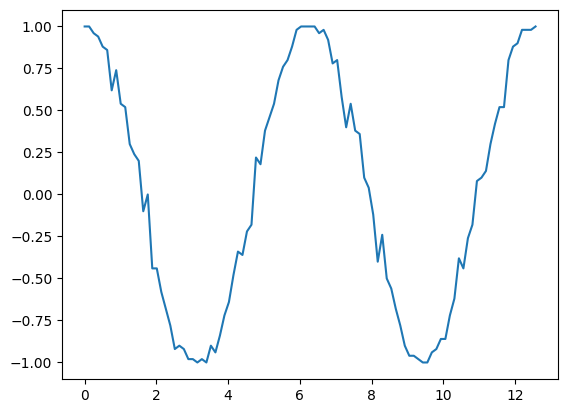

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

exp_vals = [estimator_result[i].data.evs for i in range(101)]

ax.plot(angles, exp_vals)

plt.show()